[22:00:10] WARNING: not removing hydrogen atom without neighbors
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganGenerator
[22:00:11] DEPRECATION WARNING: please use MorganG

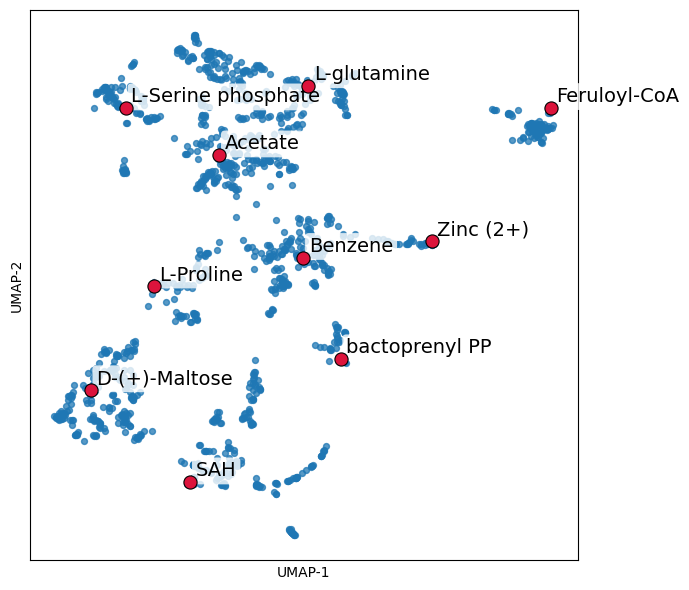

In [55]:
import json
from pprint import pprint
from collections import Counter
import re
import requests
import matplotlib.pyplot as plt
import time
import pandas as pd

with open("../public/ligifyDB3.json", "r") as f:
    data = json.load(f)


# PLOT LIGAND STRUCTURAL DIVERSITY

all_smiles = []

for i in data:
    for l in i["candidate_ligands"]:
        if l['smiles'] not in all_smiles:
            all_smiles.append(l['smiles'])


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Optional, List
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

plt.rcParams['svg.fonttype'] = 'none'

# Optional libs
try:
    import scipy.sparse as sp
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

try:
    import hdbscan
    _HAS_HDBSCAN = True
except Exception:
    _HAS_HDBSCAN = False

import umap  # from umap-learn

# %% [markdown]
# UMAP visualization of ligands from SMILES
# - Requires: rdkit-pypi, umap-learn, numpy, pandas, matplotlib, scipy (recommended)
# - Optional: hdbscan for clustering (commented block below)

# %%
# If needed, (un)comment the next lines to install:
# %pip install rdkit-pypi umap-learn numpy pandas matplotlib scipy hdbscan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Optional, List, Dict, Any
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# Optional libs
try:
    import scipy.sparse as sp
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

try:
    import hdbscan
    _HAS_HDBSCAN = True
except Exception:
    _HAS_HDBSCAN = False

import umap  # from umap-learn


# ---------------------- Helpers ----------------------
def _canon_single_smiles(val: str) -> Optional[str]:
    """Canonicalize a single SMILES string; return None if invalid."""
    try:
        m = Chem.MolFromSmiles(str(val))
        if m is None:
            return None
        Chem.SanitizeMol(m)
        return Chem.MolToSmiles(m)
    except Exception:
        return None

def sanitize_and_canonicalize_smiles(df: pd.DataFrame, smiles_col: str = "smiles") -> pd.DataFrame:
    """Parse, sanitize, and canonicalize SMILES. Drops invalid rows and duplicates."""
    if smiles_col not in df.columns:
        # try a couple common variants
        for c in df.columns:
            if c.lower() in {"smiles", "smile", "sm"}:
                smiles_col = c
                break
        else:
            raise ValueError("Could not find a SMILES column; set smiles_col correctly.")

    mols: List[Chem.Mol] = []
    canon: List[str] = []
    keep_rows: List[int] = []

    for i, s in enumerate(df[smiles_col].astype(str).tolist()):
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        try:
            Chem.SanitizeMol(m)
            csmi = Chem.MolToSmiles(m)  # canonical
            mols.append(m)
            canon.append(csmi)
            keep_rows.append(i)
        except Exception:
            continue

    out = df.iloc[keep_rows].copy().reset_index(drop=True)
    out["smiles"] = canon
    out["mol"] = mols
    out = out.drop_duplicates(subset=["smiles"]).reset_index(drop=True)
    return out


def morgan_fingerprints(
    mols: List[Chem.Mol],
    radius: int = 2,
    nbits: int = 2048,
    use_chirality: bool = True
) -> np.ndarray:
    """Return binary Morgan fingerprints as a (n_mols, nbits) uint8 numpy array."""
    arrs = []
    for m in mols:
        bv = AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits, useChirality=use_chirality)
        a = np.zeros((nbits,), dtype=np.uint8)
        DataStructs.ConvertToNumpyArray(bv, a)
        arrs.append(a)
    return np.asarray(arrs, dtype=np.uint8)


def umap_embed(
    X: np.ndarray,
    metric: str = "jaccard",
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    random_state: int = 42
) -> np.ndarray:
    """UMAP to 2D. Uses sparse matrices for Jaccard/Dice if SciPy available."""
    if metric not in {"jaccard", "dice", "hamming"}:
        raise ValueError("metric must be one of: jaccard, dice, hamming")

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=("hamming" if metric in {"jaccard", "dice"} and not _HAS_SCIPY else metric),
        random_state=random_state,
        verbose=False,
    )

    if metric in {"jaccard", "dice"} and _HAS_SCIPY:
        Xs = sp.csr_matrix(X)
        Y = reducer.fit_transform(Xs)
    else:
        Y = reducer.fit_transform(X.astype(np.float32))
    return Y


def plot_umap(
    df: pd.DataFrame,
    x_col: str = "x",
    y_col: str = "y",
    color_by: Optional[str] = None,      # background coloring by a categorical column
    annotate_by: Optional[str] = None,   # annotate first N points by a column
    title: str = "Ligand UMAP",
    annotate_max: int = 30,
    s: int = 18,
    specials: Optional[List[Any]] = None,
    match_on: str = "smiles",            # column to match specials against ("smiles" or e.g. "name")
    base_alpha: float = 0.75
):
    """
    Plot a UMAP scatter. Optionally overlay 'specials' (specific molecules) with custom colors/labels.

    specials can be:
      - a list of strings: interpreted as values in `match_on` (e.g., SMILES or names)
      - a list of dicts with keys:
          {"value": <string>, "label": <string>, "color": <matplotlib color>, "size": <int>, "marker": <str>}
        - 'value' is required; label/color/size/marker are optional.

    If match_on == "smiles", each special's 'value' is canonicalized before matching.
    """
    fig = plt.figure(figsize=(7, 6))

    # ---- Background points (all ligands) ----
    if color_by and color_by in df.columns:
        cats = df[color_by].astype(str).fillna("NA")
        for cat in sorted(cats.unique()):
            sel = df[cats == cat]
            plt.scatter(sel[x_col], sel[y_col], s=s, label=str(cat), alpha=base_alpha)
        plt.legend(title=color_by, loc="best", frameon=False)
    else:
        plt.scatter(df[x_col], df[y_col], s=s, alpha=base_alpha)

    # ---- Optional quick annotations for the first few points ----
    if annotate_by and annotate_by in df.columns:
        for _, row in df.head(annotate_max).iterrows():
            plt.annotate(str(row[annotate_by])[:30], (row[x_col], row[y_col]), fontsize=8, alpha=0.85)

    # ---- Overlay specials (custom colors + labels for specific molecules) ----
    if specials:
        # Normalize specials to a list of dicts
        norm_specials: List[Dict[str, Any]] = []
        for item in specials:
            if isinstance(item, str):
                norm_specials.append({"value": item})
            elif isinstance(item, dict) and "value" in item:
                norm_specials.append(item)
            else:
                raise ValueError("Each special must be a string or a dict with a 'value' key.")

        # If matching on SMILES, canonicalize the 'value's to align with df['smiles']
        if match_on == "smiles":
            df_vals = df["smiles"].astype(str)
            specials_map = []
            for spec in norm_specials:
                raw_val = spec["value"]
                can = _canon_single_smiles(raw_val)
                if can is None:
                    print(f"[warn] Skipping special (invalid SMILES): {raw_val}")
                    continue
                spec["__match_value__"] = can
                specials_map.append(spec)
        else:
            if match_on not in df.columns:
                raise ValueError(f"match_on='{match_on}' is not a column in df.")
            specials_map = []
            for spec in norm_specials:
                spec["__match_value__"] = str(spec["value"])
                specials_map.append(spec)

        # Draw each special (bigger size, custom color, optional marker), annotate its label
        not_found = []
        for spec in specials_map:
            mv = spec["__match_value__"]
            label = spec.get("label", spec.get("value", mv))
            color = spec.get("color", "pink")
            size = int(spec.get("size", max(60, s * 5)))
            marker = spec.get("marker", "o")

            sel = df[df[match_on].astype(str) == mv]
            if sel.empty:
                not_found.append(spec.get("value", mv))
                continue

            plt.scatter(sel[x_col], sel[y_col], s=size, marker=marker, edgecolor="black",
                        linewidths=0.8, color=color, label=None, zorder=5)

            # Annotate each matching point
            for _, row in sel.iterrows():
                plt.annotate(str(label), (row[x_col], row[y_col]),
                             fontsize=14,
                             xytext=(4, 4), textcoords="offset points",
                             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, lw=0, alpha=0.8)
                             )

        if not_found:
            print(f"[info] Specials not found in embedding (after matching on '{match_on}'): {not_found}")

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.xticks([])
    plt.yticks([])
    # plt.title(title)
    plt.tight_layout()
    plt.savefig("../../../Desktop/Inkscape/LigifyDB/Ligand_Diversity.svg", format="svg", dpi=500)
    plt.show()


def ligands_to_umap(
    df: pd.DataFrame,
    smiles_col: str = "smiles",
    label_col: Optional[str] = None,
    color_by: Optional[str] = None,
    radius: int = 2,
    nbits: int = 2048,
    metric: str = "jaccard",
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    random_state: int = 42,
    cluster: bool = False
) -> pd.DataFrame:
    """
    Full pipeline: sanitize -> FPS -> UMAP (-> optional HDBSCAN).
    Returns a new DataFrame with columns: smiles, x, y, (label/color columns preserved), cluster (if requested).
    """
    work = sanitize_and_canonicalize_smiles(df, smiles_col=smiles_col)
    if work.empty:
        raise ValueError("No valid SMILES after sanitization.")

    X = morgan_fingerprints(work["mol"].tolist(), radius=radius, nbits=nbits, use_chirality=True)
    Y = umap_embed(
        X,
        metric=metric,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )
    work = work.drop(columns=["mol"]).copy()
    work["x"] = Y[:, 0]
    work["y"] = Y[:, 1]

    # Optional clustering
    if cluster:
        if not _HAS_HDBSCAN:
            print("Note: hdbscan not installed; skipping clustering.")
        else:
            labels = hdbscan.HDBSCAN(min_cluster_size=5).fit_predict(Y)
            work["cluster"] = labels

    # Keep label/color columns if they exist in the input df
    keep_cols = ["smiles", "x", "y"]
    for col in [label_col, color_by]:
        if col and col in df.columns and col not in keep_cols:
            keep_cols.insert(1, col)

    extra_cols = [c for c in work.columns if c not in keep_cols]
    # Ensure cluster stays if present
    if "cluster" in work.columns and "cluster" not in keep_cols:
        keep_cols = keep_cols + ["cluster"]
        extra_cols.remove("cluster")

    # Return with a clean column order
    return work[keep_cols]


# ---------------------- Example usage ----------------------
# Provide your own df with at least a 'smiles' column. Optionally add:
# - a 'name' column to annotate
# - a 'family' (or any categorical) column to color points
#
# Example demo (toggle on if you want to test quickly):

df = pd.DataFrame({
        "smiles": all_smiles
    })

# --- Run the pipeline (edit arguments as needed) ---
# If you already have a df, just run this:
df_emb = ligands_to_umap(df, smiles_col="smiles",
                         label_col="name", color_by="family",
                         radius=2, nbits=2048, metric="jaccard",
                         n_neighbors=15, min_dist=0.1,
                         random_state=42, cluster=True)
#
specials = [
    {"value": "c1ccccc1", "label": "Benzene", "color": "crimson"},
    {"value": "C(CC(=O)N)[C@@H](C(=O)[O-])[NH3+]", "label": "L-glutamine", "color": "crimson"},
    # {"value": "[Fe+3]", "label": "Iron (3+)", "color": "crimson"},
    {"value": "C([C@@H]1[C@H]([C@@H]([C@H]([C@H](O1)O[C@@H]2[C@H](OC([C@@H]([C@H]2O)O)O)CO)O)O)O)O", "label": "D-(+)-Maltose", "color": "crimson"},
    {"value": "CC(C)(COP(=O)([O-])OP(=O)([O-])OC[C@@H]1[C@H]([C@H]([C@@H](O1)N2C=NC3=C(N=CN=C32)N)O)OP(=O)([O-])[O-])[C@H](C(=O)NCCC(=O)NCCSC(=O)/C=C/C4=CC(=C(C=C4)O)OC)O", "label": "Feruloyl-CoA", "color": "crimson"},
    {"value": "C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)CSCC[C@@H](C(=O)[O-])[NH3+])O)O)N", "label": "SAH", "color": "crimson"},
    {"value": "CC(=CCC/C(=C/CC/C(=C/CC/C(=C\\CC/C(=C\\CC/C(=C\\CC/C(=C\\CC/C(=C\\CC/C(=C\\CC/C(=C\\CC/C(=C\\COP(=O)([O-])OP(=O)([O-])[O-])/C)/C)/C)/C)/C)/C)/C)/C)/C)/C)C", "label": "bactoprenyl PP", "color": "crimson"},
    {"value": "C1C[C@H]([NH2+]C1)C(=O)[O-]", "label": "L-Proline", "color": "crimson"},
    {"value": "CC(=O)[O-]", "label": "Acetate", "color": "crimson"},
    {"value": "[Zn+2]", "label": "Zinc (2+)", "color": "crimson"},
    {"value": "C([C@@H](C(=O)[O-])[NH3+])OP(=O)([O-])[O-]", "label": "L-Serine phosphate", "color": "crimson"},
]

plot_umap(df_emb, color_by="family", title="Ligand UMAP (highlights)",
          specials=specials, match_on="smiles")
